In [2]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
mushroom_dataset = pd.read_csv('mushroom_dataset.csv')
mushroom_dataset.head(10)

,class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season
0,p;15.26;x;g;o;f;e;;w;16.95;17.09;s;y;w;u;w;t;g...
1,p;16.6;x;g;o;f;e;;w;17.99;18.19;s;y;w;u;w;t;g;...
2,p;14.07;x;g;o;f;e;;w;17.8;17.74;s;y;w;u;w;t;g;...
3,p;14.17;f;h;e;f;e;;w;15.77;15.98;s;y;w;u;w;t;p...
4,p;14.64;x;h;o;f;e;;w;16.53;17.2;s;y;w;u;w;t;p;...
5,p;15.34;x;g;o;f;e;;w;17.84;18.79;s;y;w;u;w;t;p...
6,p;14.85;f;h;o;f;e;;w;17.71;16.89;s;y;w;u;w;t;g...
7,p;14.86;x;h;e;f;e;;w;17.03;17.44;s;y;w;u;w;t;p...
8,p;12.85;f;g;o;f;e;;w;17.27;18.69;s;y;w;u;w;t;p...
9,p;13.55;f;g;e;f;e;;w;16.04;16.88;s;y;w;u;w;t;p...


In [4]:
mushroom_dataset = pd.read_csv('mushroom_dataset.csv',sep=';')
mushroom_dataset.head(10)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


## Row Col Count

In [5]:
mushroom_dataset.shape

(61069, 21)

## Finding a target-> selecting 'class'

In [6]:
print(mushroom_dataset['season'].unique())

print(mushroom_dataset['class'].unique())
mushroom_dataset.isnull().sum()

['w' 'u' 'a' 's']
['p' 'e']


class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

# Correlation

In [7]:
# mushroom_dataset_correlation=mushroom_dataset.corr()
#without preprocessing we cannot directly convert the entire dataset to form correlation
mushroom_numerical_features_only=mushroom_dataset.select_dtypes(include=['number'])

mushroom_numerical_features_only_corr=mushroom_numerical_features_only.corr()
mushroom_numerical_features_only_corr


,cap-diameter,stem-height,stem-width
cap-diameter,1.00000,0.422560,0.695330
stem-height,0.42256,1.000000,0.436117
stem-width,0.69533,0.436117,1.000000


<Axes: >

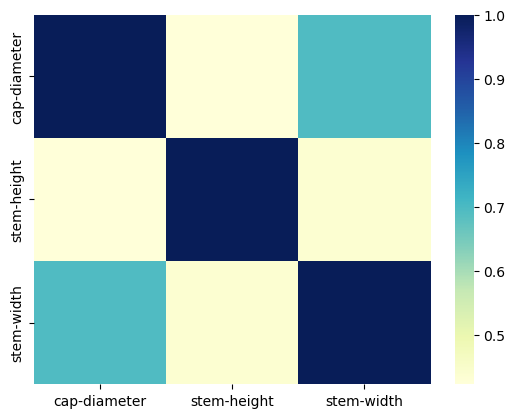

In [8]:
sns.heatmap(mushroom_numerical_features_only_corr,cmap = 'YlGnBu')

### Numerical data are mostly loosely correlated, with only two instances reaching almost 0.7. The rest are less than 0.5, ie very low dependence

# Imbalance

In [9]:
mushroom_dataset['class'].value_counts()


class
p    33888
e    27181
Name: count, dtype: int64

#### P: 33888     N:27181 So no, there’s an imbalance between the numbers of poisonous and edible mushrooms and it might create prediction errors


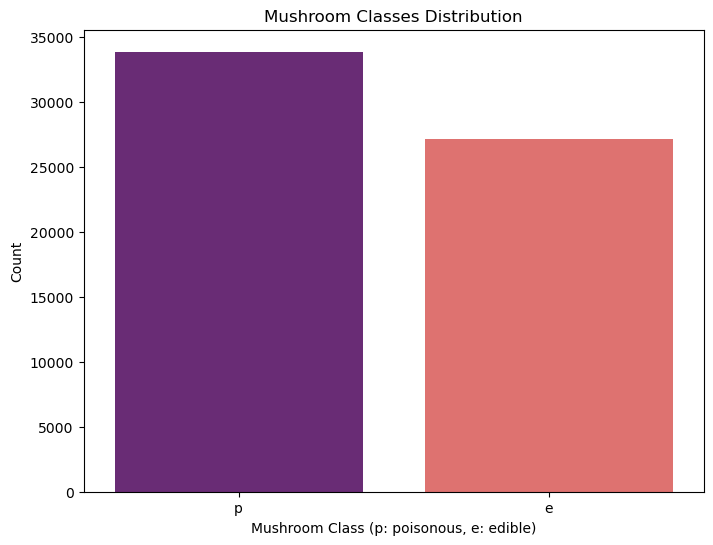

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class',hue='class', data=mushroom_dataset, palette='magma',legend=False)
plt.xlabel('Mushroom Class (p: poisonous, e: edible)')
plt.ylabel('Count')
plt.title('Mushroom Classes Distribution')
plt.show()

# EDA--> Exploratory Data Analysis.

In [11]:
mushroom_dataset.head(20) # first 5 data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


In [12]:
mushroom_dataset.shape

(61069, 21)

In [13]:
mushroom_dataset.info() #overall stat of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

### Numerical vs Categorical features number

In [14]:
num_data=mushroom_dataset.select_dtypes(include='number').columns
cat_data=mushroom_dataset.select_dtypes(include='object').columns

print(f'There are {len(num_data)} numerical features vs {len(cat_data)} categorical features')

There are 3 numerical features vs 18 categorical features


In [15]:
mushroom_dataset.describe().T  #t for transpose

,count,mean,std,min,25%,50%,75%,max
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91


In [16]:
mushroom_dataset.select_dtypes(include='object').describe().T

,count,unique,top,freq
class,61069,2,p,33888
cap-shape,61069,7,x,26934
cap-surface,46949,11,t,8196
cap-color,61069,12,n,24218
does-bruise-or-bleed,61069,2,f,50479
gill-attachment,51185,7,a,12698
gill-spacing,36006,3,c,24710
gill-color,61069,12,w,18521
stem-root,9531,5,s,3177
stem-surface,22945,8,s,6025


#### Since you cant find min max avg of categorical data like numerical one, frequency unique and top are listed

In [17]:
mushroom_dataset.select_dtypes(include='number').var() #you cant find variance of object type

cap-diameter     27.718592
stem-height      11.357014
stem-width      100.720394
dtype: float64

### **Skew in numerical features**

📐 What is Skewness?
Skewness measures the asymmetry of the distribution of a dataset.

Skewness = 0 → Perfectly symmetrical (e.g., normal distribution)

Skewness < 0 → Left-skewed (long tail on the left)

Skewness > 0 → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

📊 Interpretation of Skewness Values:

Skewness Value	Interpretation

~ 0	Symmetrical (normal-ish)

0 to ±0.5	Fairly symmetrical

±0.5 to ±1	Moderately skewed

greater than ±1	Highly skewed

In [18]:
mushroom_dataset.select_dtypes(include='number').skew()

cap-diameter    3.822844
stem-height     2.020904
stem-width      2.164957
dtype: float64

### ** Skewness Interpretation**

*ID (0.448): Fairly symmetrical – no strong skew.

*CREDIT_SCORE (-0.226): Slightly left-skewed – not a concern.

*VEHICLE_OWNERSHIP (-1.729): Highly left-skewed – most values are 1 or 0; likely a categorical variable.

*MARRIED (-0.341): Slightly left-skewed – not a big issue.

*CHILDREN (-0.080): Almost symmetrical – no transformation needed.

*POSTAL_CODE (2.987): Strong right-skew – likely due to many unique codes; should be treated as categorical.

*ANNUAL_MILEAGE (-0.510): Moderately left-skewed – may benefit from transformation.

*SPEEDING_VIOLATIONS (3.900): Highly right-skewed – most people have few or no violations; some have many.

*DUIS (5.609): Extremely right-skewed – majority have zero DUIs; a few have multiple.

*PAST_ACCIDENTS (4.346): Strong right-skew – most have few accidents; some have many.

*OUTCOME (0.313): Fairly symmetrical – distribution looks balanced.



### Histograms and Box Plot
#### To find the distributions and outlier in the each feature

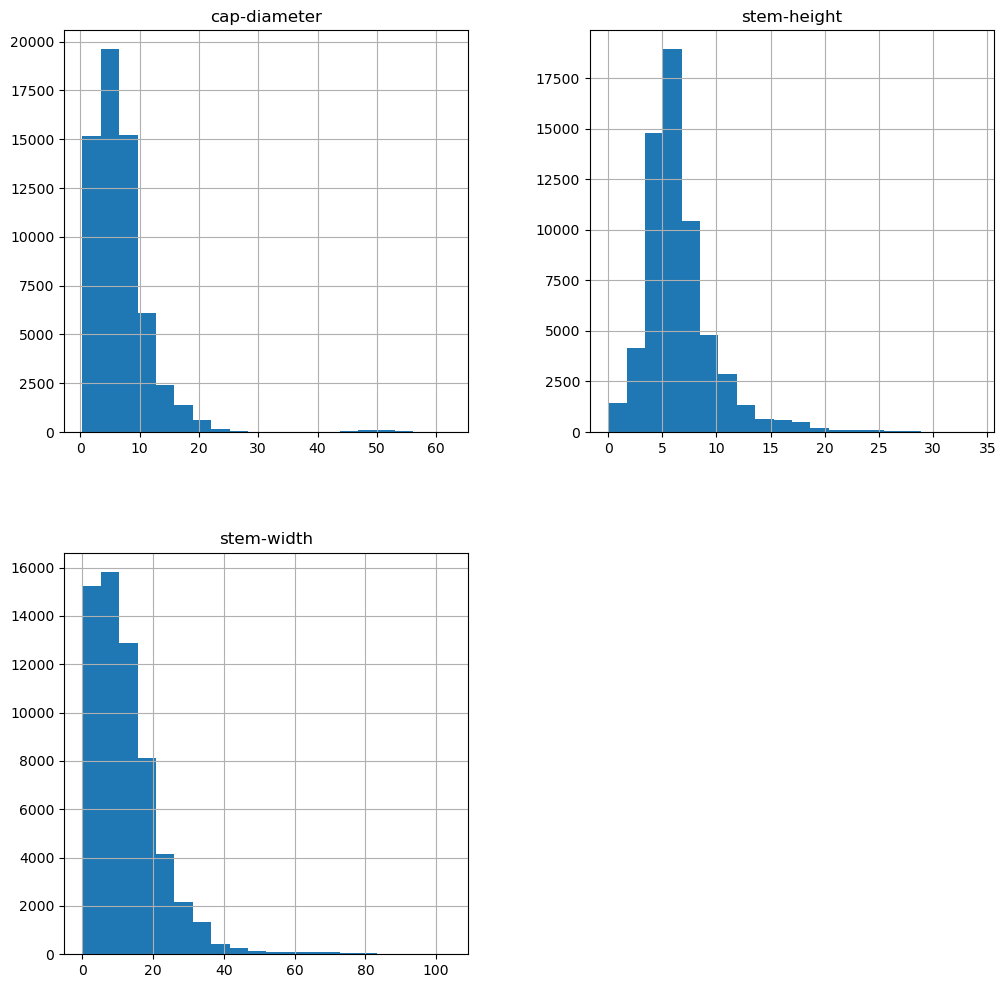

In [19]:
mushroom_dataset.select_dtypes(include='number').hist(figsize=(12,12),bins=20)
plt.show()

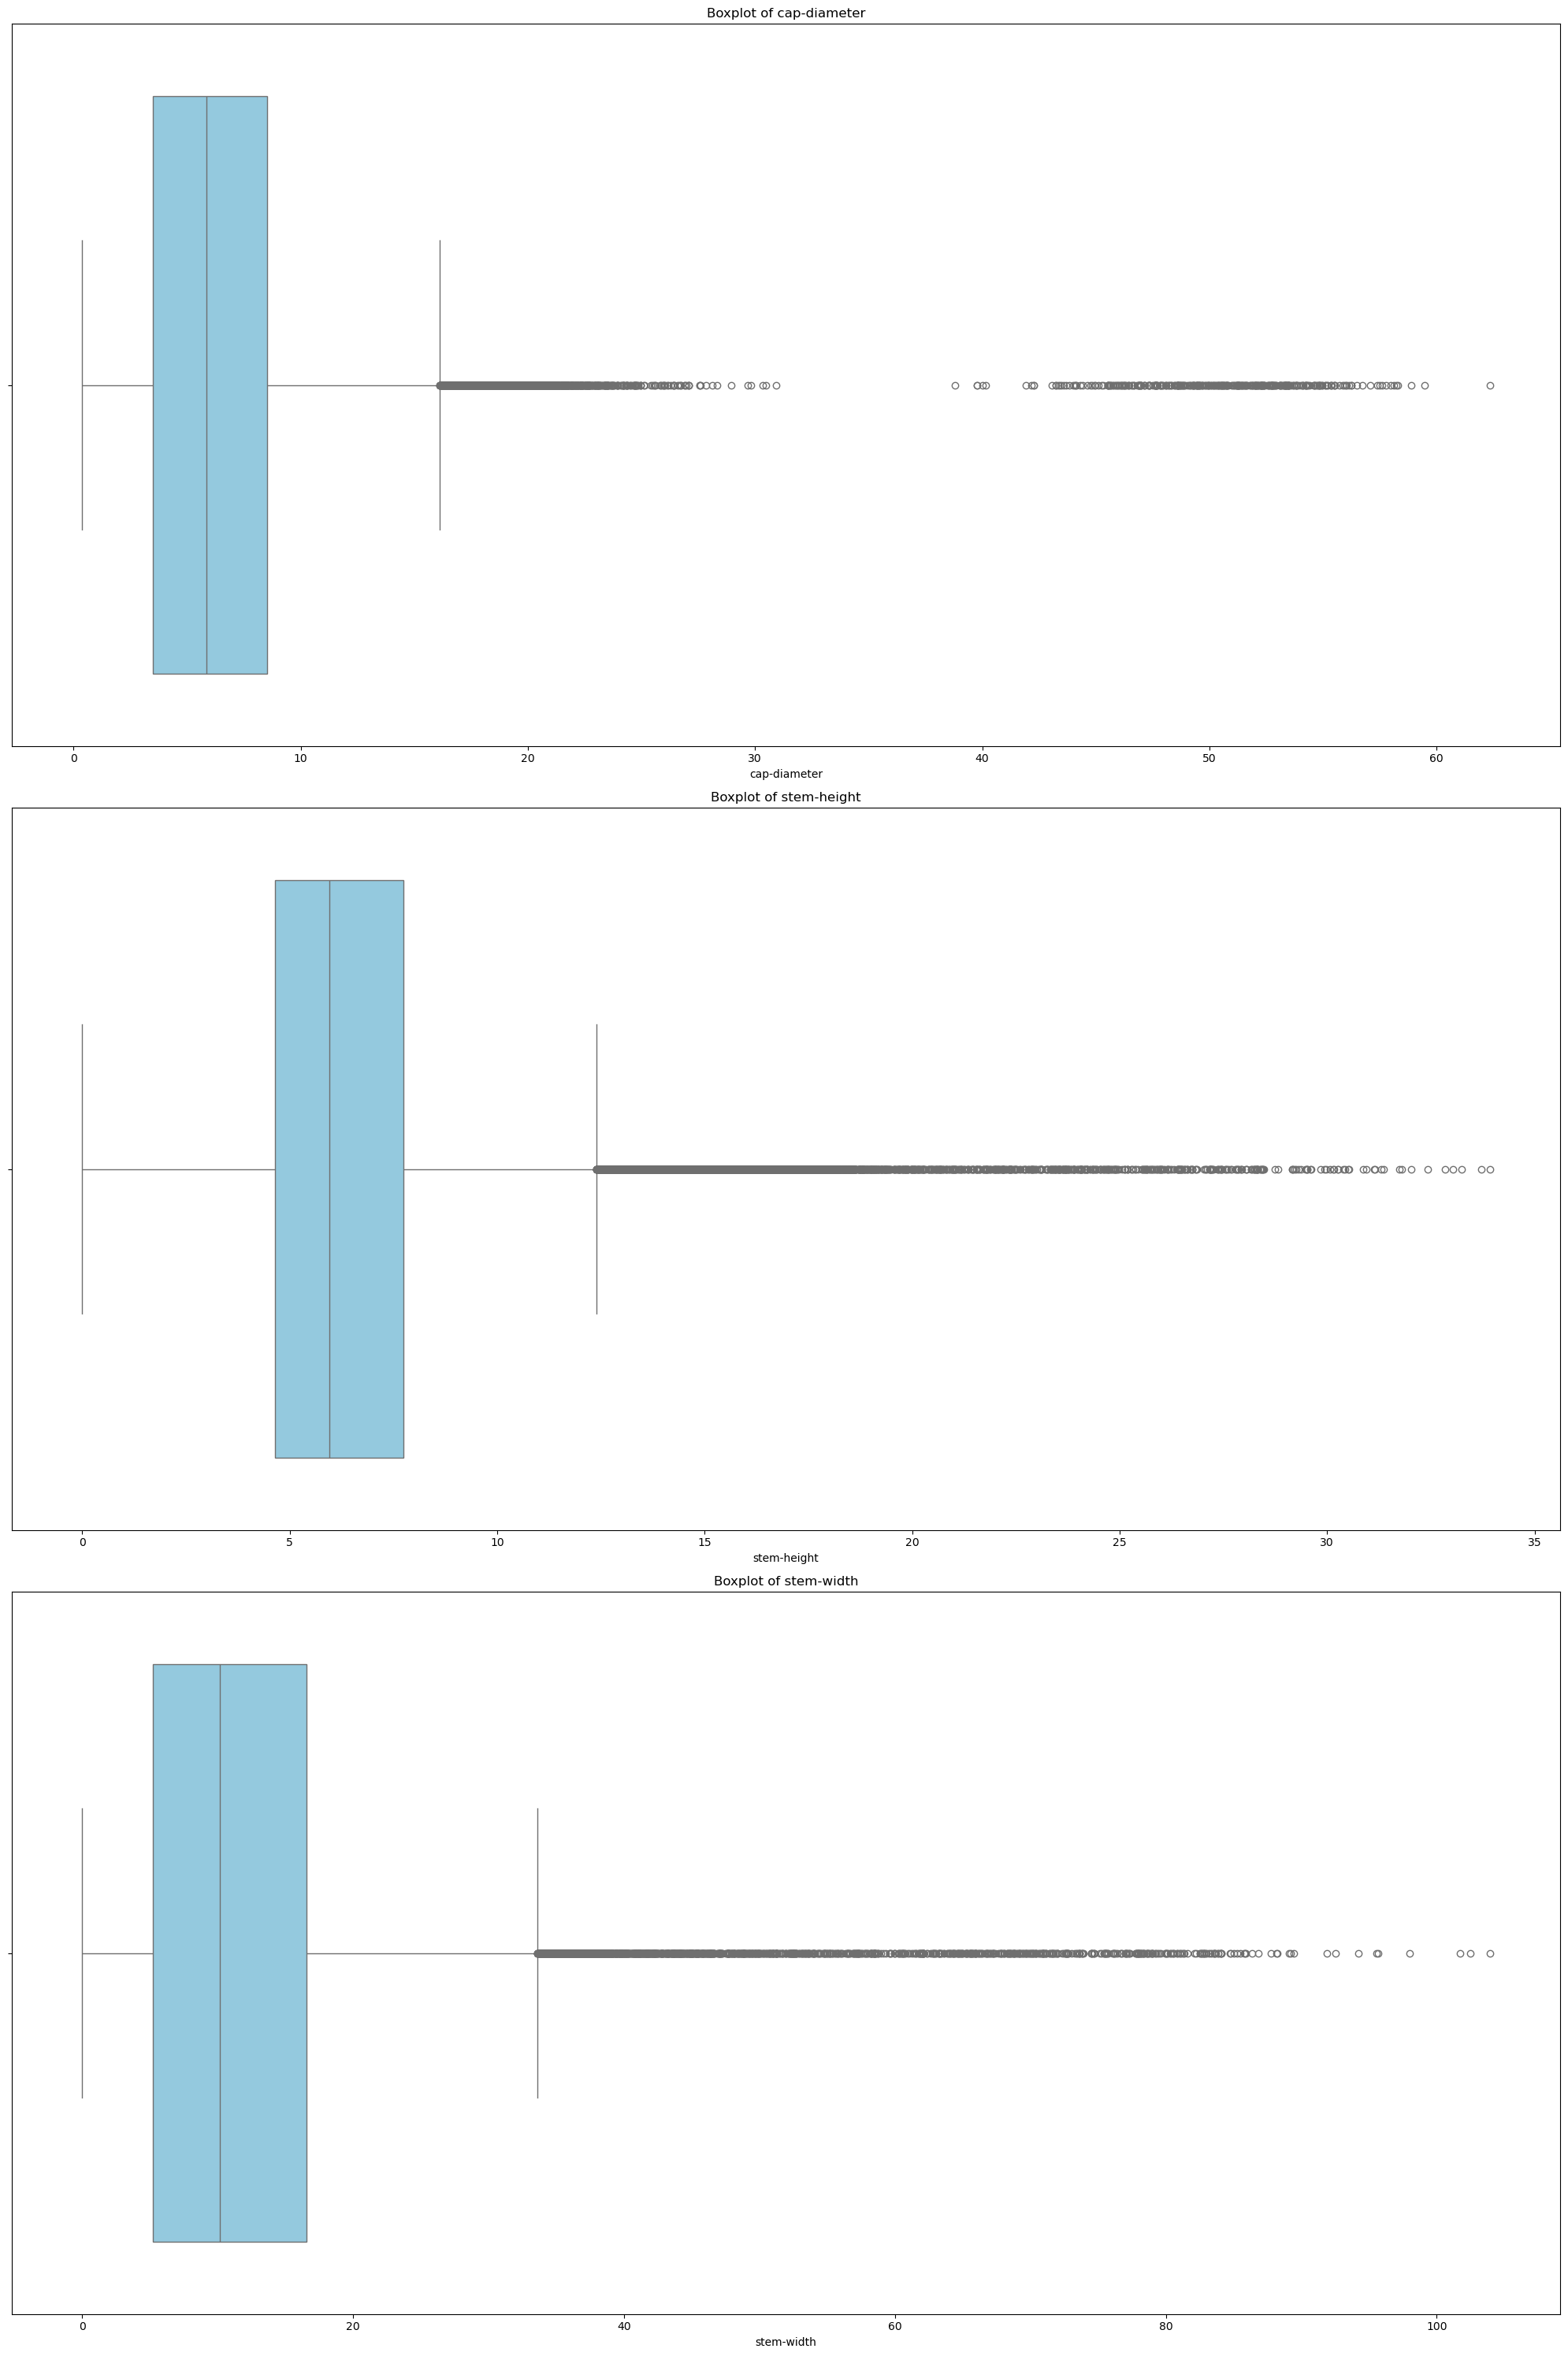

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = mushroom_dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=mushroom_dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


### Boxplot Analysis of Numerical Features

This code generates boxplots for each numerical feature in the `mushroom_dataset` to visualize the distribution of data and identify any outliers. Here's a breakdown of how the code works:

1. **Imports:**
   - `matplotlib.pyplot` (as `plt`): Used for creating static, animated, and interactive plots.
   - `seaborn` (as `sns`): A statistical data visualization library that makes it easy to generate complex visualizations.

2. **Selects Numerical Columns:**
   - The line `mushroom_dataset.select_dtypes(include=['int64', 'float64'])` selects all columns in the dataset that contain numerical data types (either integers or floating point numbers).

3. **Sets Up the Figure:**
   - `plt.figure(figsize=(20, 30))`: This creates a large figure with a width of 20 inches and a height of 30 inches to ensure all the boxplots fit properly on the page, especially if there are many numerical features.

4. **Generates Boxplots for Each Numerical Feature:**
   - The loop `for i, col in enumerate(numeric_cols, 1):` iterates through each numerical column and creates a boxplot for each one.
   - `sns.boxplot(x=mushroom_dataset[col], color='skyblue')`: This generates the boxplot for the given feature, with the data from that column and a color of 'skyblue'.
   - `plt.title(f'Boxplot of {col}', fontsize=12)`: Adds a title to each plot, indicating the feature being visualized.
   - `plt.tight_layout()`: Ensures the layout is adjusted so that the subplots don’t overlap and everything fits properly.

5. **Displays the Boxplots:**
   - `plt.show()`: Displays the boxplots on the screen.

### Purpose:
The goal of this analysis is to provide a visual representation of the distribution of each numerical feature in the dataset. Boxplots are particularly useful for:
- Showing the median, quartiles, and range of the data.
- Identifying potential outliers (data points outside the whiskers).
- Comparing the spread and central tendency of different numerical features.

This type of visualization is essential for understanding the underlying distribution of your data and detecting any potential data quality issues, such as outliers, that might need further attention.


# Data Preprocessing Begin

In [21]:
print(mushroom_dataset.isnull().sum())
print(mushroom_dataset.select_dtypes(include='number').columns.tolist()) 

class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64
['cap-diameter', 'stem-height', 'stem-width']


#### So none of the 3 numeric feature columns have missing values, all missing values are on the categorical features. Time to find unique values from missing featues to further asssess the situation

In [22]:
print(f'Unique values in cap-surface: {mushroom_dataset['cap-surface'].unique()}')
print(f'Unique values in gill-attachment: {mushroom_dataset['gill-attachment'].unique()}')
print(f'Unique values in gill-spacing: {mushroom_dataset['gill-spacing'].unique()}')
print(f'Unique values in stem-root: {mushroom_dataset['stem-root'].unique()}')
print(f'Unique values in stem-surface: {mushroom_dataset['stem-surface'].unique()}')
print(f'Unique values in veil-type: {mushroom_dataset['veil-type'].unique()}')
print(f'Unique values in veil-color: {mushroom_dataset['veil-color'].unique()}')
print(f'Unique values in ring-type: {mushroom_dataset['ring-type'].unique()}')
print(f'Unique values in spore-print-color: {mushroom_dataset['spore-print-color'].unique()}')


Unique values in cap-surface: ['g' 'h' nan 't' 'y' 'e' 's' 'l' 'd' 'w' 'i' 'k']
Unique values in gill-attachment: ['e' nan 'a' 'd' 's' 'x' 'p' 'f']
Unique values in gill-spacing: [nan 'c' 'd' 'f']
Unique values in stem-root: ['s' nan 'b' 'r' 'c' 'f']
Unique values in stem-surface: ['y' nan 's' 'k' 'i' 'h' 't' 'g' 'f']
Unique values in veil-type: ['u' nan]
Unique values in veil-color: ['w' 'y' nan 'n' 'e' 'u' 'k']
Unique values in ring-type: ['g' 'p' 'e' 'l' 'f' 'm' nan 'r' 'z']
Unique values in spore-print-color: [nan 'w' 'p' 'k' 'r' 'u' 'n' 'g']


#### Every missing value is from categorical data, so using mean is out of the window. Trying to evaluate necessary imputation method

In [23]:
print(mushroom_dataset['cap-surface'].value_counts())

print(mushroom_dataset['gill-attachment'].value_counts())

print(mushroom_dataset['gill-spacing'].value_counts())

print(mushroom_dataset['stem-root'].value_counts())

print(mushroom_dataset['stem-surface'].value_counts())

print(mushroom_dataset['veil-type'].value_counts())

print(mushroom_dataset['veil-color'].value_counts())

print(mushroom_dataset['ring-type'].value_counts())

print(mushroom_dataset['spore-print-color'].value_counts())

cap-surface
t    8196
s    7608
y    6341
h    4974
g    4724
d    4432
e    2584
k    2303
i    2225
w    2150
l    1412
Name: count, dtype: int64
gill-attachment
a    12698
d    10247
x     7413
p     6001
e     5648
s     5648
f     3530
Name: count, dtype: int64
gill-spacing
c    24710
d     7766
f     3530
Name: count, dtype: int64
stem-root
s    3177
b    3177
r    1412
f    1059
c     706
Name: count, dtype: int64
stem-surface
s    6025
y    4940
i    4396
t    2644
g    1765
k    1581
f    1059
h     535
Name: count, dtype: int64
veil-type
u    3177
Name: count, dtype: int64
veil-color
w    5474
y     527
n     525
u     353
k     353
e     181
Name: count, dtype: int64
ring-type
f    48361
e     2435
z     2118
l     1427
r     1399
p     1265
g     1240
m      353
Name: count, dtype: int64
spore-print-color
k    2118
p    1259
w    1212
n    1059
g     353
u     182
r     171
Name: count, dtype: int64


In [24]:
mushroom_dataset.isnull().sum()

class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

#### OBSERVATION-> Among 61069 data points, the least amount of values missing from a column is 2471 and highest 57892.Veil-type has only one unique value and that is too 3177 out of 61069, so that column is best dropped. Stem-surface, gill-spacing, spore print color,ring-type, veil-color  has high domminance of the top unique values, so mode/most frequent values can be used. While cap-surface, gill-attachment and stem-root values doesnt have the same dominance as the others, we are keeping it to most frequent imputer for now

In [25]:
from sklearn.impute import SimpleImputer

impute_most_frequent = SimpleImputer(strategy='most_frequent')


for column in ['gill-spacing', 'stem-surface', 'veil-color', 'ring-type', 'spore-print-color','cap-surface','gill-attachment','stem-root']:
    mushroom_dataset[column] = impute_most_frequent.fit_transform(mushroom_dataset[[column]]).ravel()


##### .ravel(): This method converts the 2D array returned by fit_transform() into a 1D array, making it compatible for assignment back to the DataFrame column. Ravel was needed for simple imputer to work

In [26]:
mushroom_dataset=mushroom_dataset.drop('veil-type',axis=1)

In [27]:
mushroom_dataset.isnull().sum()

class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-root               0
stem-surface            0
stem-color              0
veil-color              0
has-ring                0
ring-type               0
spore-print-color       0
habitat                 0
season                  0
dtype: int64

#### Time to encode data

##### Since there a lot of categories and the unique values dont seem like they can be categorized as low, medium high ie ordered classification from unique values. One hot encoder is used

In [28]:
#separating caterorical and numerical features
categorical_features = mushroom_dataset.select_dtypes(include=['object']).columns.tolist()
numerical_features = mushroom_dataset.select_dtypes(include=['number']).columns.tolist()

categorical_features.remove('class') # remove target from being encoded

mushroom_dataset_encoded=pd.get_dummies(mushroom_dataset, columns=categorical_features, drop_first=True)



### One-Hot Encoding with `pd.get_dummies()`

In this section, we apply one-hot encoding to the categorical features of the `mushroom_dataset` using `pandas.get_dummies()`.

The **one-hot encoding** process converts categorical variables into a series of binary (0/1) columns. Each column represents one possible value for the categorical feature, with `1` indicating the presence of that category and `0` indicating the absence.




### One-Hot Encoding Explanation

- **`mushroom_dataset`**: This is the original dataset containing both categorical and numerical features.

- **`columns=categorical_features`**: This parameter specifies which columns of the dataset should be one-hot encoded. The `categorical_features` variable contains the list of column names that are categorical in nature.

- **`drop_first=True`**: This option ensures that the first category of each categorical feature is dropped to prevent **multicollinearity**. This is important when using the encoded features in certain machine learning models (like linear regression), as it prevents the "dummy variable trap," where the first category can be perfectly predicted from the other columns. Dropping the first category reduces redundancy.

  For example, if a column has three categories (`Red`, `Green`, `Blue`), one-hot encoding with `drop_first=True` will create two columns: one for `Green` and one for `Blue`. `Red` is inferred when both columns are `0`.

  **Example**:
  
  | Color (Original) |
  |------------------|
  | Red              |
  | Green            |
  | Blue             |

  After one-hot encoding with `drop_first=True`:

  | Green | Blue |
  |-------|------|
  | 0     | 0    |
  | 1     | 0    |
  | 0     | 1    |

  In this case:
  - `Green` and `Blue` are the two resulting columns (since `Red` was dropped).
  - If the color is `Green`, the row has `1` in the `Green` column and `0` in the `Blue` column, and so on.


##### Scale numerical data

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
mushroom_dataset_encoded[numerical_features]=scaler.fit_transform(mushroom_dataset_encoded[numerical_features])

#### Label Encode target=class

In [30]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
mushroom_dataset_encoded['class']=label_encoder.fit_transform(mushroom_dataset_encoded['class'])

In [31]:
mushroom_dataset_encoded.head(10)

,class,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
0,1,0.240155,0.499705,0.164469,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,1,0.261782,0.530366,0.175055,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,1,0.220949,0.524764,0.170725,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,1,0.222563,0.464917,0.153787,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,0.230148,0.487323,0.165528,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
5,1,0.241446,0.525943,0.180830,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
6,1,0.233538,0.522111,0.162545,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,1,0.233699,0.502064,0.167838,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
8,1,0.201259,0.509139,0.179867,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,1,0.212556,0.472877,0.162448,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [43]:
mushroom_dataset_encoded.shape

(61069, 103)

# Data Splitting

#### Since at the beginning of the project, we saw that our classs was imbalanced, so we stratify using our target class

In [32]:
from sklearn.model_selection import train_test_split

mushroom_dataset_x=mushroom_dataset_encoded.drop('class',axis=1)
mushroom_dataset_y=mushroom_dataset_encoded['class']

x_train,x_test,y_train,y_test=train_test_split(mushroom_dataset_x,mushroom_dataset_y, test_size=0.3,random_state=42,stratify=mushroom_dataset_y) #train set 70 p, test set 30 p


print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (42748, 102)
X_test shape: (18321, 102)
y_train shape: (42748,)
y_test shape: (18321,)


### Stratified Splitting
This creates training and testing sets with class proportions representative of the original dataset. Using stratified splitting can prevent model bias, and is most effective for imbalanced datasets or datasets where categories aren't represented equally.

# Model Training

#### Selecting KNN and Logistic Regression as the classic ML models

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

logistic_regression=LogisticRegression(random_state=42) # random_state= 42 to shuffle the data. just like splitting. So far setting the values from 30 to 60 didnt change a thing
k_nearest_neighbor=KNeighborsClassifier(n_neighbors=3) #  Less can introduce noise, high value can oversmooth and miss local pattern. I originally set the value to 5 and resulted 1 false positive. Then set the value to 7 to get 4 false positives. Finally set to 3 for 0 false positives or false negatives

logistic_regression.fit(x_train,y_train)
k_nearest_neighbor.fit(x_train,y_train)

y_predict_k_nearest_neighbor=k_nearest_neighbor.predict(x_test)
y_predict_logistic_regression=logistic_regression.predict(x_test)

#### Neural Network

Multi-layer Perceptron (MLP) is a supervised learning algorithm that learns a function 
 by training on a dataset, where 
 is the number of dimensions for input and 
 is the number of dimensions for output. Given a set of features 
 and a target 
, it can learn a non-linear function approximator for either classification or regression. It is different from logistic regression, in that between the input and the output layer, there can be one or more non-linear layers, called hidden layers. Figure 1 shows a one hidden layer MLP with scalar output.

https://scikit-learn.org/stable/_images/multilayerperceptron_network.png
Figure 1 : One hidden layer MLP.
The leftmost layer, known as the input layer, consists of a set of neurons 
 representing the input features. Each neuron in the hidden layer transforms the values from the previous layer with a weighted linear summation 
, followed by a non-linear activation function 
 - like the hyperbolic tan function. The output layer receives the values from the last hidden layer and transforms them into output values.

The module contains the public attributes coefs_ and intercepts_. coefs_ is a list of weight matrices, where weight matrix at index 
 represents the weights between layer 
 and layer 
. intercepts_ is a list of bias vectors, where the vector at index 
 represents the bias values added to layer 
.

The advantages of Multi-layer Perceptron are:

Capability to learn non-linear models.

Capability to learn models in real-time (on-line learning) using partial_fit.

The disadvantages of Multi-layer Perceptron (MLP) include:

MLP with hidden layers have a non-convex loss function where there exists more than one local minimum. Therefore different random weight initializations can lead to different validation accuracy.

MLP requires tuning a number of hyperparameters such as the number of hidden neurons, layers, and iterations.

MLP is sensitive to feature scaling.

Please see Tips on Practical Use section that addresses some of these disadvantages.



## Multi-layer Perceptron classifier.

    This model optimizes the log-loss function using LBFGS or stochastic gradient descent.
### Classification Using Sklearn Multi-layer Perceptron
Multi-Layer Perceptrons (MLPs) are a type of neural network commonly used for classification tasks where the relationship between features and target labels is non-linear. They are particularly effective when traditional linear models are insufficient to capture complex patterns in data. This includes image recognition, text classification and many more. In this article we’ll focus on how to implement classification using MLPs.

#### Architecture of Multi-Layer Perceptron Classifier
Multi-Layer Perceptron (MLP) has multiple layers of connected nodes (also known as neurons) and is frequently used for different machine-learning tasks, including classification and regression.

Its architecture is given below:

1. `Input Layer`: This layer is composed of neurons that receive the features of the dataset. Each neuron in the input layer represents a specific feature of the data. The number of neurons in the input layer equals the number of features in the dataset.

2. `Hidden Layer`: One or more hidden layers may exist between the input and output layers. The number of hidden layers and neurons in each hidden layer is determined by hyperparameters

3. `Output Layer`: The final predictions or outputs are generated by the output layer using the data processed in the hidden levels.

For binary classification: the output layer typically contains a single neuron with a sigmoid activation function. The sigmoid function outputs a probability between 0 and 1.
For multi-class classification: the output layer has as many neurons as there are classes in the task with each neuron producing a probability for a particular class. The probabilities are computed using the softmax activation function which ensures the sum of all output neuron probabilities equals 1.
#### Key Steps in MLP Classification:

1. `Initialization`: Weights and biases are initialized with small random values.

2. `Forward Propagation`: Data is passed through the layers and the activation function introduces non-linearity helping the network learn complex relationships.

3. `Loss Calculation`: A loss function such as cross-entropy for classification measures how well the model’s predictions match the actual labels.

4. `Backpropagation`: The network updates its weights and biases to minimize the loss using optimization techniques like Gradient Descent.

5. `Prediction`: After training the network uses forward propagation with updated weights to predict outcomes on new data.

Although MLPs are highly capable of modeling complex relationships their performance can be sensitive to hyperparameters like the number of layers, number of neurons and choice of activation functions. Thus proper fine tuning is crucial.

### Choosing the right hidden layer size:
`Too many neurons/layers`: May result in overfitting, where the model is too complex and captures noise in the data.

`Too few neurons/layers`: May underfit, where the model is too simple and can't capture the underlying patterns in the data.

### Key points about max_iter:
`Default Value`: max_iter is set to 200 by default.

`Higher Values`: If your model is not converging (i.e., the loss does not decrease adequately), you can increase the number of iterations.

`Convergence`: The model may stop earlier if it converges before reaching the specified number of iterations, depending on the stopping criteria.

`Effect`: Setting a high value can lead to longer training times, especially for large datasets. If set too low, the model might not have enough iterations to learn well.


### hidden layers in tuple format significance
In MLPClassifier and similar models in scikit-learn, the hidden_layer_sizes parameter is often specified as a tuple. The reason it's given in tuples (of length two or more) is to represent the number of neurons in each hidden layer of the network.

The tuple (a, b) means you have two hidden layers:
The first hidden layer has a neurons.
The second hidden layer has b neurons.
You can specify any number of hidden layers and their sizes by providing a tuple with more elements. For example:

(100,): One hidden layer with 100 neurons.
(50, 100): Two hidden layers: the first with 50 neurons, the second with 100 neurons.
(50, 100, 50): Three hidden layers: 50 neurons, 100 neurons, and 50 neurons in each layer, respectively.

In [34]:
from sklearn.neural_network import MLPClassifier

Neural_Network=MLPClassifier(hidden_layer_sizes=(136,70),max_iter=500,random_state=42)

Neural_Network.fit(x_train,y_train)
y_predict_neural_network=Neural_Network.predict(x_test)

# Model Evaluation

### Confusion Matrix

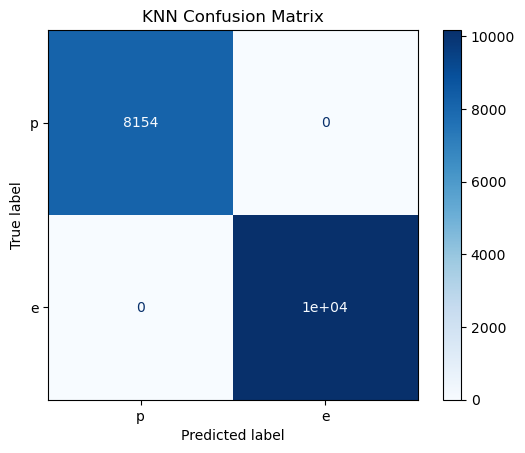

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
target_names = mushroom_dataset['class'].unique()
cm_log = confusion_matrix(y_test, y_predict_k_nearest_neighbor)
ConfusionMatrixDisplay(cm_log, display_labels=target_names).plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

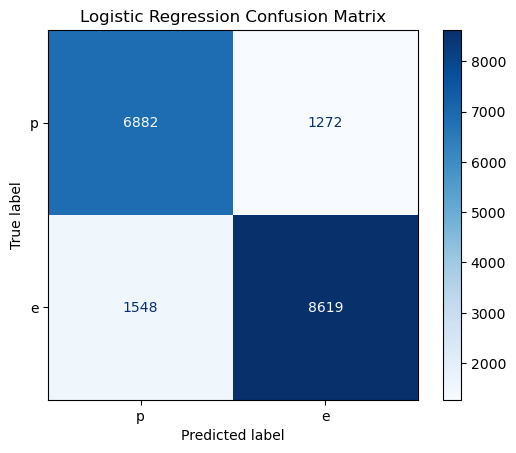

In [36]:
target_names = mushroom_dataset['class'].unique()
cm_log = confusion_matrix(y_test, y_predict_logistic_regression)
ConfusionMatrixDisplay(cm_log, display_labels=target_names).plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

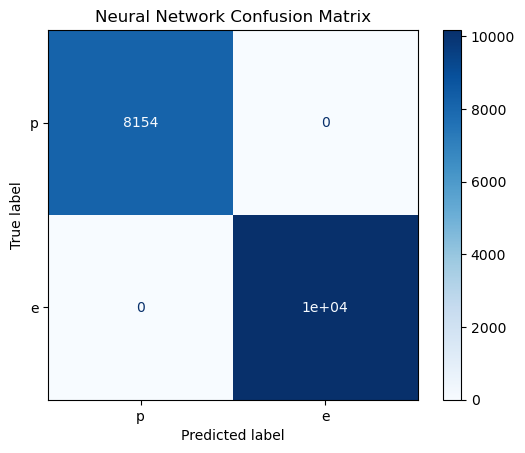

In [37]:
target_names = mushroom_dataset['class'].unique()
cm_log = confusion_matrix(y_test, y_predict_neural_network)
ConfusionMatrixDisplay(cm_log, display_labels=target_names).plot(cmap="Blues")
plt.title("Neural Network Confusion Matrix")
plt.show()

### ROC Curve

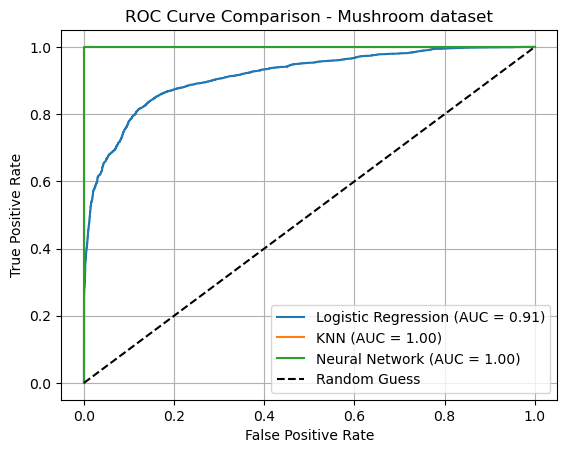

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
models={
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(136,70),max_iter=500,random_state=42)
    
}
for name, model in models.items():
    # Fit
    model.fit(x_train, y_train)

    # Predict probabilities for class 1 (survived)
    y_probs = model.predict_proba(x_test)[:, 1]

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Mushroom dataset")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Bar Chart of accuracy

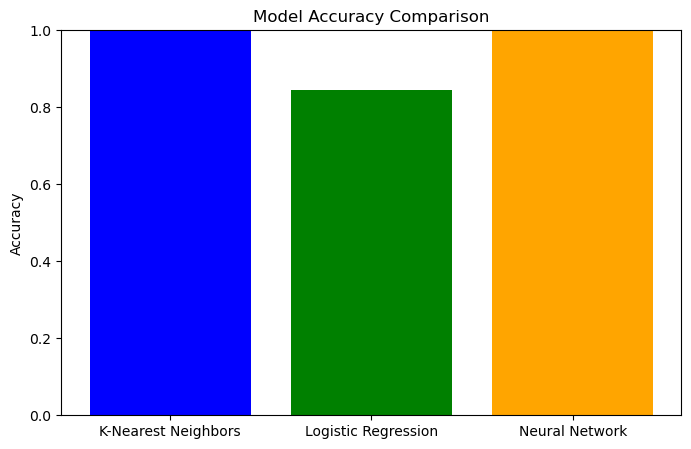

Accuracy for
KNN: 1.0
Logistic Regression: 0.8460782708367447
Neural Network: 1.0


In [39]:
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Accuracy scores
accuracy_knn = accuracy_score(y_test, y_predict_k_nearest_neighbor)
accuracy_logistic_regression = accuracy_score(y_test, y_predict_logistic_regression)
accuracy_neural_network = accuracy_score(y_test, y_predict_neural_network)

# Plotting
models = ['K-Nearest Neighbors', 'Logistic Regression', 'Neural Network']
accuracies = [accuracy_knn, accuracy_logistic_regression, accuracy_neural_network]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])


plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 1])  

# Display the plot
plt.show()
print('Accuracy for')
print(f'KNN: {accuracy_knn}\nLogistic Regression: {accuracy_logistic_regression}\nNeural Network: {accuracy_neural_network}')


### Bar chart for Precision

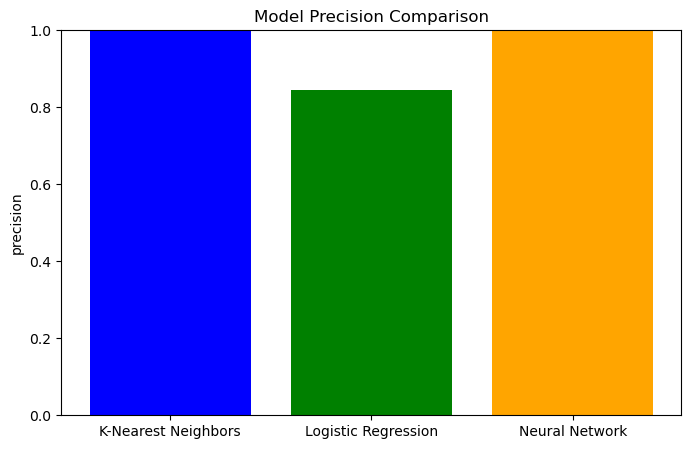

Precision for
KNN: 1.0
Logistic Regression: 0.8713982408249924
Neural Network: 1.0


In [40]:
precision_knn = precision_score(y_test, y_predict_k_nearest_neighbor)
precision_logistic_regression = precision_score(y_test, y_predict_logistic_regression)
precision_neural_network = precision_score(y_test, y_predict_neural_network)

# Plotting
models = ['K-Nearest Neighbors', 'Logistic Regression', 'Neural Network']
precisions = [precision_knn, precision_logistic_regression, precision_neural_network]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])


plt.ylabel('precision')
plt.title('Model Precision Comparison')
plt.ylim([0, 1])  

# Display the plot
plt.show()
print('Precision for')
print(f'KNN: {precision_knn}\nLogistic Regression: {precision_logistic_regression}\nNeural Network: {precision_neural_network}')


### Bar chart for recall

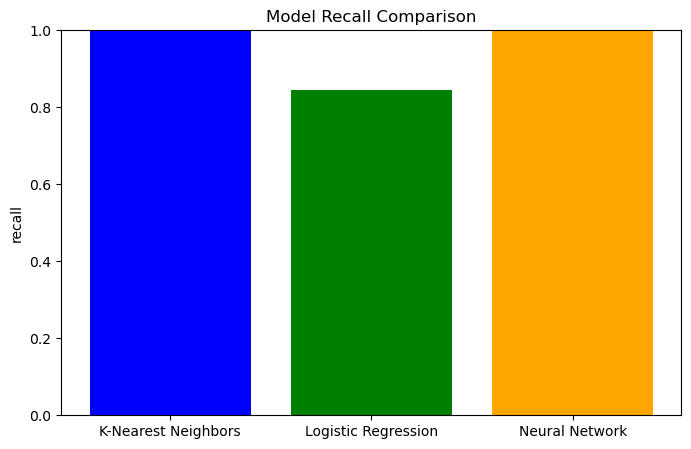

Recall for
KNN: 1.0
Logistic Regression: 0.8477426969607554
Neural Network: 1.0


In [41]:
recall_knn = recall_score(y_test, y_predict_k_nearest_neighbor)
recall_logistic_regression = recall_score(y_test, y_predict_logistic_regression)
recall_neural_network = recall_score(y_test, y_predict_neural_network)

# Plotting
models = ['K-Nearest Neighbors', 'Logistic Regression', 'Neural Network']
recalls = [recall_knn, recall_logistic_regression, recall_neural_network]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])


plt.ylabel('recall')
plt.title('Model Recall Comparison')
plt.ylim([0, 1])  

# Display the plot
plt.show()
print('Recall for')
print(f'KNN: {recall_knn}\nLogistic Regression: {recall_logistic_regression}\nNeural Network: {recall_neural_network}')


### Bar chart for f1 score comparison

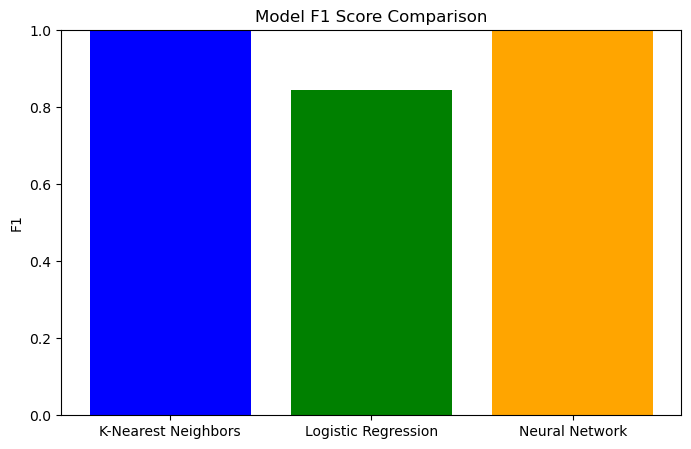

F1 scores for
KNN: 1.0
Logistic Regression: 0.8594077176189052
Neural Network: 1.0


In [42]:
f1_knn = f1_score(y_test, y_predict_k_nearest_neighbor)
f1_logistic_regression = f1_score(y_test, y_predict_logistic_regression)
f1_neural_network = f1_score(y_test, y_predict_neural_network)

# Plotting
models = ['K-Nearest Neighbors', 'Logistic Regression', 'Neural Network']
f1s = [f1_knn, f1_logistic_regression, f1_neural_network]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])


plt.ylabel('F1')
plt.title('Model F1 Score Comparison')
plt.ylim([0, 1])  

# Display the plot
plt.show()
print('F1 scores for')
print(f'KNN: {f1_knn}\nLogistic Regression: {f1_logistic_regression}\nNeural Network: {f1_neural_network}')